In [ ]:
# Instructions for running this code the first time:
# install conda if you dont have it (or download python 3.10 yourself)
# with conda you can create environments so packages wont conflict with eachother
# use: conda create -n SDenv python=3.10
# and: conda activate SDenv
# Then install the following packages with: pip install ipykernel numpy matplotlib scikit-learn pandas seaborn tqdm tensorflow
# tensorflow for gpu if you have Linux/WSL2
# we should probably switch to torch to make things easier

# About the dataset: this notebook expects a structure like this : ../data/data_files and ../data/data_info
# you will have to change this if your data folder is elsewhere

In [ ]:
# run this once to double check
# !pip install numpy matplotlib scikit-learn pandas seaborn tqdm

# Bose-Einstein Condensate Soliton Detection
## Practical Reproduction of the SolDet Training Flow

This notebook is a standalone reproduction of the main SolDet pipeline from arXiv:2111.04881 for dark-soliton analysis in BEC absorption images.

What we cover here:
1. Load and inspect the .npy image dataset (132x164).
2. Train a 3-class classifier for coarse event type.
3. Train a 41-bin object detector for position localization.
4. Run PIE + quality-estimation steps in a standalone way.
5. Evaluate with confusion matrices, ROC curves, and Grad-CAM checks.

In [3]:
# quick sanity check for the runtime we agreed on
# target is python 3.10.20
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:36:49) [MSC v.1944 64 bit (AMD64)]
Python executable: c:\Users\sbrad\.conda\envs\soldet_reproduce\python.exe


## 1. Environment Setup and Imports

Quick environment checks and imports before we touch data or models.

In [ ]:
# pulling in the usual stack for this reproduction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm
import random
import os

# model/training stack
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import backend as K

# reporting + evaluation helpers
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, roc_auc_score, f1_score
)

# keep plots readable and consistent
plt.style.use('default')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}") # 2.15
print(f"NumPy version: {np.__version__}") # 1.24.3


TensorFlow version: 2.15.0
NumPy version: 1.24.3

GPU Devices: []
GPU Available: False


In [5]:
# these are the local paths this notebook expects
DATA_DIR = Path('../data')
DATA_FILES_DIR = DATA_DIR / 'data_files' / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' / 'data_roster.csv'

print(f"Data directory exists: {DATA_FILES_DIR.exists()}")
print(f"Labels file exists: {LABELS_FILE.exists()}")

Data directory exists: True
Labels file exists: True


## 2. Dataset Loading

We load images from the data folders and match each file to roster metadata.
Each sample is a 132x164 absorption image, plus labels/position annotations when available.

In [6]:
# bring in the roster so filenames line up with labels
labels_df = pd.read_csv(LABELS_FILE, index_col=0)
print(f"Labels dataframe shape: {labels_df.shape}")
print(f"\nFirst few rows:")
labels_df.head()

Labels dataframe shape: (16478, 12)

First few rows:


,file_name,label_v1,3-agree,label_v2,label_v3,excitation_position,excitation_PIE,excitation_quality,soldet_CNN,soldet_OD,soldet_PIE,soldet_QE
/data/data_files/class-1/2019-08-02_0004_20190523_BEC_F1_NewODT_DMD_42.npy,/data/data_files/class-1/2019-08-02_0004_20190...,1,1,1,1,[110.35077157540614],[1],[0.7305203942861915],NaN,NaN,NaN,NaN
/data/data_files/class-1/2019-07-19_0028_20190523_BEC_F1_NewODT_DMD_037.npy,/data/data_files/class-1/2019-07-19_0028_20190...,1,0,1,1,[41.63773334829051],[1],[0.24901817761481015],NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-16_0012_20190523_BEC_F1_NewODT_DMD_208.npy,/data/data_files/class-0/2019-07-16_0012_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-2/2019-07-15_0011_20190523_BEC_F1_NewODT_DMD_025.npy,/data/data_files/class-2/2019-07-15_0011_20190...,2,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-12_0061_20190523_BEC_F1_NewODT_DMD_109.npy,/data/data_files/class-0/2019-07-12_0061_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    """
    Load BEC images and labels from disk.
    
    Args:
        data_dir: Path to data_files folder
        labels_df: DataFrame with labels indexed by file path
        max_samples: Maximum number of samples to load (None = all)
        shuffle_seed: Random seed for shuffling
    
    Returns:
        images: array of shape (N, 132, 164, 1)
        labels: array of shape (N,) with integer labels
        positions: list of position lists
        file_paths: list of file paths
    """
    # Discover available class folders dynamically (class-0, class-1, ..., class-9)
    class_dirs = [d for d in data_dir.glob('class-*') if d.is_dir()]

    def class_sort_key(path_obj):
        suffix = path_obj.name.split('-')[-1]
        return int(suffix) if suffix.isdigit() else suffix

    class_dirs = sorted(class_dirs, key=class_sort_key)
    print(f"Discovered class folders: {[d.name for d in class_dirs]}")

    all_files = []
    for class_dir in class_dirs:
        all_files.extend(sorted(class_dir.glob('*.npy')))
    
    print(f"Found {len(all_files)} .npy files")
    
    # Shuffle if requested
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    
    # Limit samples
    if max_samples is not None:
        all_files = all_files[:max_samples]
    
    images = []
    labels = []
    positions = []
    file_paths = []
    
    print(f"Loading {len(all_files)} samples...")
    for file_path in tqdm(all_files):
        try:
            # load each image bundle
            data_dict = np.load(file_path, allow_pickle=True).item()
            
            # this field is the actual normalized image
            img = data_dict['masked_data'].reshape(132, 164, 1)
            
            # match file path to roster index
            # roster uses '/data/data_files/class-x/filename.npy'
            rel_path = '/data/' + '/'.join(file_path.parts[-3:])  # use tail path pieces for roster lookup
            
            if rel_path in labels_df.index:
                label_row = labels_df.loc[rel_path]
                label = label_row['label_v3']
                
                # parse excitation positions from the csv string field
                pos_str = label_row['excitation_position']
                if pd.isna(pos_str) or pos_str == '':
                    pos = []
                else:
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                
                images.append(img)
                labels.append(int(label))
                positions.append(pos)
                file_paths.append(str(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue
    
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    
    print(f"\nLoaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Label distribution: {np.bincount(labels)}")
    
    return images, labels, positions, file_paths

In [8]:
# this can take a while, so keep max_samples=1000 while iterating
print("Loading dataset...")
images, labels, positions, file_paths = load_bec_dataset(
    DATA_FILES_DIR,
    labels_df,
    max_samples=None,
    shuffle_seed=42,
)

# check if importing went well
print(f"\nUnique labels: {np.unique(labels)}")
print(f"Images data type: {images.dtype}")
print(f"Images value range: [{images.min():.3f}, {images.max():.3f}]")

Loading dataset...
Discovered class folders: ['class-0', 'class-1', 'class-2', 'class-8', 'class-9']
Found 16478 .npy files
Loading 16478 samples...


100%|██████████| 16478/16478 [05:38<00:00, 48.71it/s]



Loaded 16478 images
Image shape: (16478, 132, 164, 1)
Label distribution: [ 1130  3212  1036     0     0     0     0     0   879 10221]

Unique labels: [0 1 2 8 9]
Images data type: float32
Images value range: [-0.473, 3.492]


## 3. Data Exploration and Visualization

A quick pass to check class balance and visually confirm what each class looks like.

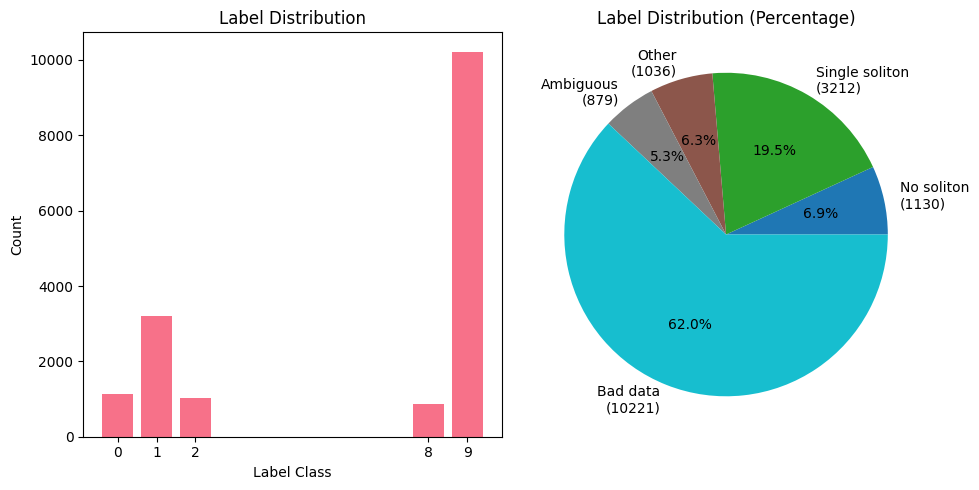

Label descriptions:
  0: No soliton - 1130 samples
  1: Single soliton - 3212 samples
  2: Other - 1036 samples
  8: Ambiguous - 879 samples
  9: Bad data - 10221 samples


In [9]:
# quick look at class balance before we split
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
unique, counts = np.unique(labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Label Class')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.xticks(unique)

plt.subplot(1, 2, 2)
label_names = {0: 'No soliton', 1: 'Single soliton', 2: 'Other', 8: 'Ambiguous', 9: 'Bad data'}
pie_colors = plt.cm.tab10(np.linspace(0, 1, len(unique)))
plt.pie(
    counts,
    labels=[f"{label_names.get(l, f'Class {l}')}\n({c})" for l, c in zip(unique, counts)],
    autopct='%1.1f%%',
    colors=pie_colors,
    )
plt.title('Label Distribution (Percentage)')

plt.tight_layout()
plt.show()

print("Label descriptions:")
for label in unique:
    print(f"  {label}: {label_names.get(label, f'Class {label}')} - {counts[list(unique).index(label)]} samples")

## 4. Data Preparation and Splitting

Before training we do three things:
1. Remove ambiguous/bad captures (labels 8 and 9).
2. Map labels into the 3-class setup (0->0, 1->1, 2+->2).
3. Make a stratified 90/10 train-test split.

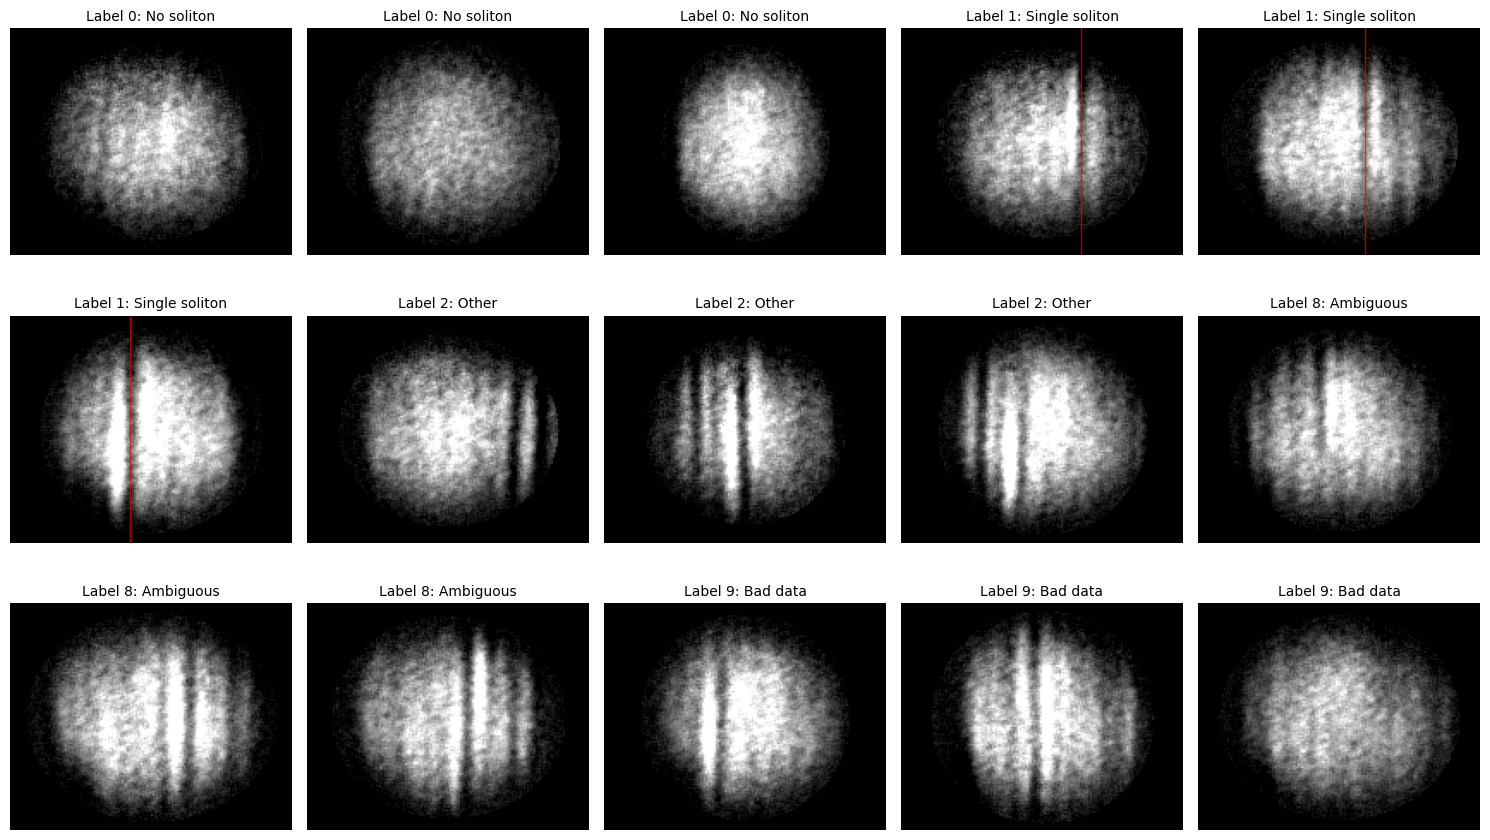

In [10]:
# sample gallery so we can eyeball what each class looks like
class_values = sorted(np.unique(labels).tolist())
max_total_plots = 15
samples_per_class = 3
n_cols = 5
n_rows = int(np.ceil(max_total_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
axes = axes.flatten()

label_names = {0: 'No soliton', 1: 'Single soliton', 2: 'Other', 8: 'Ambiguous', 9: 'Bad data'}

plot_idx = 0
for label_val in class_values:
    indices = np.where(labels == label_val)[0]
    if len(indices) == 0:
        continue

    # take a few examples per class
    sample_indices = indices[:min(samples_per_class, len(indices))]

    for idx in sample_indices:
        if plot_idx >= max_total_plots:
            break
        img = images[idx].squeeze()
        axes[plot_idx].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[plot_idx].set_title(f"Label {label_val}: {label_names.get(label_val, f'Class {label_val}')}", fontsize=10)
        axes[plot_idx].axis('off')

        # overlay annotated positions when present
        if len(positions[idx]) > 0:
            for pos in positions[idx]:
                axes[plot_idx].axvline(x=pos, color='red', linewidth=1, alpha=0.7)

        plot_idx += 1

    if plot_idx >= max_total_plots:
        break

# hide empty tiles if we run out of examples
for idx in range(plot_idx, max_total_plots):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# drop ambiguous/bad data (labels 8 and 9)
valid_mask = (labels < 8)
images_filtered = images[valid_mask]
labels_filtered = labels[valid_mask]
positions_filtered = [positions[i] for i in range(len(positions)) if valid_mask[i]]

print(f"After filtering: {len(images_filtered)} samples")
print(f"Label distribution: {np.bincount(labels_filtered)}")

# collapse labels into the 3-class setup used downstream
def map_labels_to_3class(labels):
    """Map labels to 3 classes: 0=no soliton, 1=single soliton, 2=other"""
    mapped = np.copy(labels)
    mapped[labels >= 2] = 2
    return mapped

labels_3class = map_labels_to_3class(labels_filtered)
print(f"\\n3-class label distribution: {np.bincount(labels_3class)}")

# keep a 80/20 split for train vs test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    images_filtered, labels_3class, positions_filtered,
    test_size=0.1, random_state=42, stratify=labels_3class
)

print(f"\\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

After filtering: 5378 samples
Label distribution: [1130 3212 1036]
\n3-class label distribution: [1130 3212 1036]
\nTrain set: 4840 samples
Test set: 538 samples
Train label distribution: [1017 2891  932]
Test label distribution: [113 321 104]


## 5. Custom Metrics and Loss Functions

This section defines the classifier F1 metric and the detector Metz-style loss used in the training runs below.

In [12]:
# weighted f1 proxy for classifier monitoring (same idea as soldet helper)
def f1_metric(y_true, y_pred):
    """Weighted F1 score for multi-class classification."""
    ground_positives = K.sum(y_true, axis=0)
    pred_positives = K.sum(y_pred, axis=0)
    true_positives = K.sum(y_true * y_pred, axis=0)

    precision = (true_positives + K.epsilon()) / (pred_positives + K.epsilon())
    recall = (true_positives + K.epsilon()) / (ground_positives + K.epsilon())
    f1 = 2 * (precision * recall) / (precision + recall + K.epsilon())

    weighted_f1 = f1 * ground_positives / (K.sum(ground_positives) + K.epsilon())
    return K.sum(weighted_f1)

# metz-style detector loss from the paper's detector setup
def metz_loss(y_true, y_pred):
    """
    Custom loss for object detector:
    - Channel 0: Weighted BCE for presence detection
    - Channel 1: MSE for position regression
    """
    epsilon = K.epsilon()

    # channel 0 = presence probability
    presence_true = y_true[..., 0]
    presence_pred = y_pred[..., 0]

    # upweight positives so we do not miss sparse detections
    bce = -10 * presence_true * K.log(presence_pred + epsilon) - \
          (1 - presence_true) * K.log(1 - presence_pred + epsilon)

    # channel 1 = fine position offset (only where present)
    position_true = y_true[..., 1]
    position_pred = y_pred[..., 1]

    mse = 10 * presence_true * K.square(position_true - position_pred)

    return K.sum(bce + mse)

# coarse f1 metric over detector presence bins
def f1_41(y_true, y_pred):
    """F1 score for 41-bin detection (presence channel only)"""
    presence_true = y_true[..., 0]
    presence_pred = y_pred[..., 0]

    ground_positives = K.sum(presence_true)
    pred_positives = K.sum(presence_pred)
    true_positives = K.sum(presence_true * presence_pred)

    precision = (true_positives + K.epsilon()) / (pred_positives + K.epsilon())
    recall = (true_positives + K.epsilon()) / (ground_positives + K.epsilon())

    f1 = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1

print("Custom metrics and loss functions defined.")

Custom metrics and loss functions defined.


## 6. Classifier Model Definition

We use the same overall 3-class CNN pattern as SolDet:
- five convolution blocks
- dense stack with dropout
- softmax output over three classes

In [13]:
def create_classifier():
    """3-class classifier CNN matching SolDet architecture"""
    model = Sequential([
        InputLayer(input_shape=(132, 164, 1)),
        
        # Conv block 1
        Conv2D(8, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2, 2), strides=2),
        
        # Conv block 2
        Conv2D(16, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2, 2), strides=2),
        
        # Conv block 3
        Conv2D(32, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2, 2), strides=2),
        
        # Conv block 4
        Conv2D(64, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2, 2), strides=2),
        
        # Conv block 5
        Conv2D(128, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2, 2), strides=2),
        
        # Flatten and dense layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # Output
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=[f1_metric, 'accuracy']
    )
    
    return model

# inspect architecture
classifier = create_classifier()
classifier.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 132, 164, 8)       208       
                                                                 
 max_pooling2d (MaxPooling2  (None, 66, 82, 8)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 66, 82, 16)        3216      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 33, 41, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 33, 41, 32)        12832     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 20, 32)       

In [14]:
# simple flip augmentation to match our classifier training recipe
def augment_by_flips(images, labels, seed=42):
    """
    For label==1: original + one random flip.
    For other labels: original + all three flips.
    """
    rng = np.random.default_rng(seed)
    aug_images = []
    aug_labels = []

    for img, label in zip(images, labels):
        aug_images.append(img)
        aug_labels.append(label)

        if int(label) == 1:
            flip_choice = int(rng.integers(0, 3))
            if flip_choice == 0:
                aug_images.append(np.flipud(img))
            elif flip_choice == 1:
                aug_images.append(np.fliplr(img))
            else:
                aug_images.append(np.flipud(np.fliplr(img)))
            aug_labels.append(label)
        else:
            aug_images.extend([
                np.flipud(img),
                np.fliplr(img),
                np.flipud(np.fliplr(img)),
            ])
            aug_labels.extend([label, label, label])

    return np.array(aug_images, dtype=np.float32), np.array(aug_labels, dtype=np.int32)

# cache one-hot labels for later eval plots/metrics
from tensorflow.keras.utils import to_categorical
y_test_onehot = to_categorical(y_test, num_classes=3)
print(f"Test labels shape: {y_test_onehot.shape}")

Test labels shape: (538, 3)


## 7. Train Classifier with 5-Fold Cross Validation

Classifier training runs with stratified k=5 folds to reduce dependence on one random split.

In [15]:
# run 5-fold cv so results are less split-sensitive
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical

N_SPLITS = 5
EPOCHS = 50
BATCH_SIZE = 32

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_histories = []
fold_metrics = []
best_val_f1 = -np.inf
best_fold_idx = -1
classifier = None

print("Training classifier with 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]

    X_fold_train_aug, y_fold_train_aug = augment_by_flips(
        X_fold_train,
        y_fold_train,
        seed=42 + fold_idx,
    )

    y_fold_train_onehot = to_categorical(y_fold_train_aug, num_classes=3)
    y_fold_val_onehot = to_categorical(y_fold_val, num_classes=3)

    fold_model = create_classifier()
    print(f"\nFold {fold_idx}/{N_SPLITS}")
    print(f"  Train samples (pre-aug): {len(X_fold_train)}")
    print(f"  Train samples (aug): {len(X_fold_train_aug)}")
    print(f"  Val samples: {len(X_fold_val)}")

    fold_history = fold_model.fit(
        X_fold_train_aug,
        y_fold_train_onehot,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_fold_val, y_fold_val_onehot),
        verbose=1,
    )

    val_loss, val_f1, val_acc = fold_model.evaluate(X_fold_val, y_fold_val_onehot, verbose=0)
    print(f"  Fold {fold_idx} val_loss: {val_loss:.4f}")
    print(f"  Fold {fold_idx} val_f1: {val_f1:.4f}")
    print(f"  Fold {fold_idx} val_acc: {val_acc:.4f}")

    fold_histories.append(fold_history)
    fold_metrics.append({
        'fold': fold_idx,
        'val_loss': float(val_loss),
        'val_f1': float(val_f1),
        'val_accuracy': float(val_acc),
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_fold_idx = fold_idx - 1
        classifier = fold_model

history = fold_histories[best_fold_idx]

print("\nCross-validation complete!")
for metric_row in fold_metrics:
    print(
        f"Fold {metric_row['fold']}: val_loss={metric_row['val_loss']:.4f}, "
        f"val_f1={metric_row['val_f1']:.4f}, val_acc={metric_row['val_accuracy']:.4f}"
    )

print(f"\nSelected model from fold {best_fold_idx + 1} (best val_f1={best_val_f1:.4f})")
print(f"Mean val_f1 across folds: {np.mean([m['val_f1'] for m in fold_metrics]):.4f}")

Training classifier with 5-fold cross-validation...

Fold 1/5
  Train samples (pre-aug): 3872
  Train samples (aug): 10862
  Val samples: 968
Epoch 1/50


340/340 [==============================] - 49s 130ms/step - loss: 0.7610 - f1_metric: 0.5240 - accuracy: 0.6137 - val_loss: 0.3492 - val_f1_metric: 0.7539 - val_accuracy: 0.8564
Epoch 2/50
340/340 [==============================] - 43s 126ms/step - loss: 0.3012 - f1_metric: 0.8145 - accuracy: 0.8830 - val_loss: 0.1415 - val_f1_metric: 0.9191 - val_accuracy: 0.9504
Epoch 3/50
340/340 [==============================] - 43s 125ms/step - loss: 0.1854 - f1_metric: 0.8933 - accuracy: 0.9401 - val_loss: 0.1037 - val_f1_metric: 0.9435 - val_accuracy: 0.9607
Epoch 4/50
340/340 [==============================] - 43s 125ms/step - loss: 0.1487 - f1_metric: 0.9177 - accuracy: 0.9530 - val_loss: 0.1362 - val_f1_metric: 0.9388 - val_accuracy: 0.9504
Epoch 5/50
340/340 [==============================] - 42s 125ms/step - loss: 0.1315 - f1_metric: 0.9

In [16]:
# save the fold winner for downstream steps
classifier.save('classifier_best_kfold5.keras')
print("Saved classifier model to classifier_best_kfold5.keras")

Saved classifier model to classifier_best_kfold5.keras


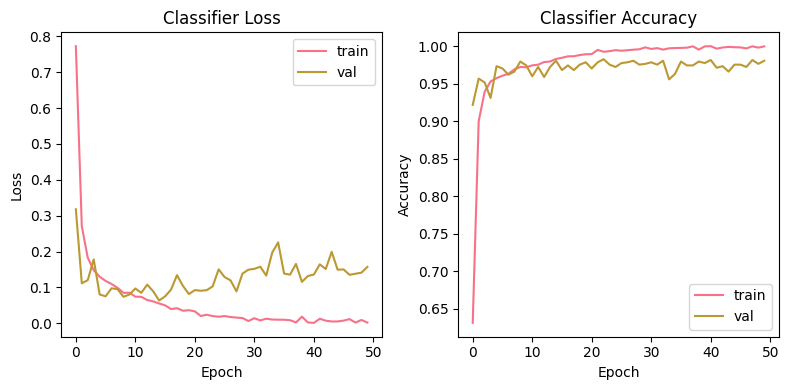

In [17]:
# training curves for the selected classifier fold
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Classifier Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test loss: 0.2195
Test accuracy: 0.9721
Test F1 proxy: 0.9724

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       113
           1     0.9752    0.9782    0.9767       321
           2     0.9320    0.9231    0.9275       104

    accuracy                         0.9721       538
   macro avg     0.9691    0.9671    0.9681       538
weighted avg     0.9720    0.9721    0.9721       538



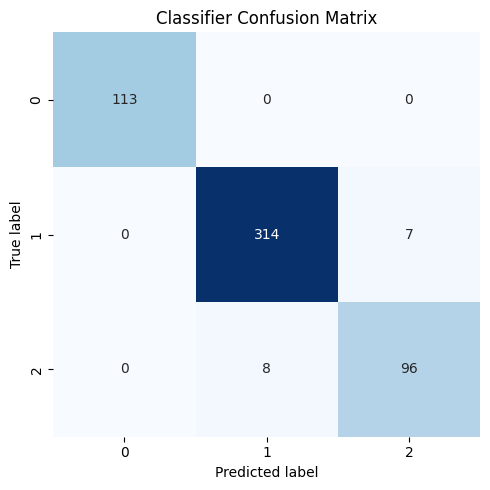

In [18]:
# held-out classifier eval
classifier_test_loss, classifier_test_f1, classifier_test_accuracy = classifier.evaluate(
    X_test,
    y_test_onehot,
    verbose=0,
)

y_test_pred = classifier.predict(X_test, verbose=0)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)
cm = confusion_matrix(y_test, y_test_pred_labels)

print(f"Test loss: {classifier_test_loss:.4f}")
print(f"Test accuracy: {classifier_test_accuracy:.4f}")
print(f"Test F1 proxy: {classifier_test_f1:.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_test_pred_labels, digits=4))

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Object Detector Data Preparation

Here we build the detector dataset from labels 0 and 1 only, then convert positions to the 41-bin representation used by the model.

In [ ]:
IMAGE_WIDTH = 164

In [ ]:
def normalize_position_list(position_list):
    if isinstance(position_list, list):
        return [float(pos) for pos in position_list]
    return []

def augment_detector_by_flips(images, positions, image_width=IMAGE_WIDTH):
    augmented_images = []
    augmented_positions = []

    for img, pos_list in zip(images, positions):
        pos_list = normalize_position_list(pos_list)
        flipped_positions = [image_width - pos for pos in pos_list]

        augmented_images.extend([
            img,
            np.fliplr(img),
            np.flipud(img),
            np.flipud(np.fliplr(img)),
        ])
        augmented_positions.extend([
            pos_list,
            flipped_positions,
            pos_list,
            flipped_positions,
        ])

    return np.array(augmented_images, dtype=np.float32), augmented_positions

def positions_to_41_labels(position_batches, image_width=IMAGE_WIDTH):
    labels_41 = np.zeros((len(position_batches), 1, image_width // 4, 2), dtype=np.float32)

    for sample_idx, position_list in enumerate(position_batches):
        for pos in normalize_position_list(position_list):
            if 0 < pos < image_width:
                bin_idx = min(int(pos // 4), (image_width // 4) - 1)
                labels_41[sample_idx, 0, bin_idx, 0] = 1.0
                labels_41[sample_idx, 0, bin_idx, 1] = (pos % 4) / 4.0

    return labels_41

def labels41_to_positions(label_array, prob_threshold=0.5, merge_threshold=4.0):
    batch_positions = []

    for sample in label_array:
        sample_positions = []
        for bin_idx in range(sample.shape[1]):
            if sample[0, bin_idx, 0] > prob_threshold:
                sample_positions.append(float(bin_idx * 4 + sample[0, bin_idx, 1] * 4))

        merged_positions = []
        for pos in sample_positions:
            if merged_positions and (pos - merged_positions[-1]) < merge_threshold:
                merged_positions[-1] = 0.5 * (merged_positions[-1] + pos)
            else:
                merged_positions.append(pos)

        batch_positions.append(merged_positions)

    return batch_positions


In [ ]:
# now build detector-specific tensors from the same split

train_detector_mask = y_train < 2
test_detector_mask = y_test < 2

X_train_det = X_train[train_detector_mask]
X_test_det = X_test[test_detector_mask]
pos_train_det = [pos_train[i] for i in range(len(pos_train)) if train_detector_mask[i]]
pos_test_det = [pos_test[i] for i in range(len(pos_test)) if test_detector_mask[i]]
y_train_det_labels = y_train[train_detector_mask]
y_test_det_labels = y_test[test_detector_mask]

X_train_det_aug, pos_train_det_aug = augment_detector_by_flips(X_train_det, pos_train_det)
y_train_det_41 = positions_to_41_labels(pos_train_det_aug)
y_test_det_41 = positions_to_41_labels(pos_test_det)

print(f"Detector train samples: {len(X_train_det)}")
print(f"Detector test samples: {len(X_test_det)}")
print(f"Detector augmented train samples: {len(X_train_det_aug)}")
print(f"Train positives: {sum(len(p) > 0 for p in pos_train_det)}")
print(f"Test positives: {sum(len(p) > 0 for p in pos_test_det)}")
print(f"Detector label tensor shape: {y_train_det_41.shape}")

Detector train samples: 3908
Detector test samples: 434
Detector augmented train samples: 15632
Train positives: 2891
Test positives: 321
Detector label tensor shape: (15632, 1, 41, 2)


## 9. Object Detector Model and Training

This is the detector architecture/training pass with Metz loss, batch size 32, and 50 epochs.

In [20]:
# detector architecture/training pass, kept close to our baseline settings
def create_object_detector():
    regularizer = tf.keras.regularizers.l1_l2()

    model = Sequential([
        InputLayer(input_shape=(132, 164, 1)),
        Conv2D(8, (5, 5), padding='same', activation='relu', activity_regularizer=regularizer),
        MaxPooling2D(pool_size=(4, 2), strides=(4, 2)),
        Conv2D(16, (5, 5), padding='same', activation='relu', activity_regularizer=regularizer),
        MaxPooling2D(pool_size=(4, 2), strides=(4, 2)),
        Conv2D(32, (5, 5), padding='same', activation='relu', activity_regularizer=regularizer),
        MaxPooling2D(pool_size=(4, 1), strides=(4, 1), padding='same'),
        Conv2D(64, (1, 5), padding='same', activation='relu', activity_regularizer=regularizer),
        MaxPooling2D(pool_size=(2, 1), strides=(2, 1), padding='same'),
        Conv2D(128, (1, 5), padding='same', activation='relu', activity_regularizer=regularizer),
        Conv2D(2, (1, 5), padding='same', activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
        loss=metz_loss,
        metrics=[f1_41],
    )
    return model

object_detector = create_object_detector()
object_detector.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_30 (Conv2D)          (None, 132, 164, 8)       208       
                                                                 
 max_pooling2d_30 (MaxPooli  (None, 33, 82, 8)         0         
 ng2D)                                                           
                                                                 
 conv2d_31 (Conv2D)          (None, 33, 82, 16)        3216      
                                                                 
 max_pooling2d_31 (MaxPooli  (None, 8, 41, 16)         0         
 ng2D)                                                           
                                                                 
 conv2d_32 (Conv2D)          (None, 8, 41, 32)         12832     
                                                                 
 max_pooling2d_32 (MaxPooli  (None, 2, 41, 32)        

In [ ]:
print("Training object detector...")
print(f"Detector training pool: {len(X_train_det_aug)} augmented samples")
print(f"Held-out test samples (kept untouched): {len(X_test_det)}\n")

# build a detector train/validation split so we can track val curves
from sklearn.model_selection import train_test_split

# makes the train/validation split keep a similar ratio of positive vs empty samples in both sets
detector_presence = (np.sum(y_train_det_41[..., 0], axis=(1, 2)) > 0).astype(np.int32)
X_det_train, X_det_val, y_det_train, y_det_val = train_test_split(
    X_train_det_aug,
    y_train_det_41,
    test_size=0.2,
    random_state=42,
    stratify=detector_presence,
 )

print(f"Detector train samples: {len(X_det_train)}")
print(f"Detector validation samples: {len(X_det_val)}")

detector_history = object_detector.fit(
    X_det_train,
    y_det_train,
    validation_data=(X_det_val, y_det_val),
    epochs=50,
    batch_size=32,
    verbose=1,
 )

print("\nObject detector training complete.")

Training object detector...
Detector training pool: 15632 augmented samples
Held-out test samples (kept untouched): 434

Detector train samples: 12505
Detector validation samples: 3127
Epoch 1/50
391/391 [==============================] - 72s 182ms/step - loss: 16.6491 - f1_41: 0.9634 - val_loss: 57.7984 - val_f1_41: 0.9138
Epoch 2/50
391/391 [==============================] - 63s 162ms/step - loss: 19.7286 - f1_41: 0.9596 - val_loss: 60.2341 - val_f1_41: 0.9320
Epoch 3/50
391/391 [==============================] - 65s 166ms/step - loss: 15.7980 - f1_41: 0.9680 - val_loss: 61.7722 - val_f1_41: 0.9219
Epoch 4/50
391/391 [==============================] - 59s 151ms/step - loss: 17.1301 - f1_41: 0.9650 - val_loss: 63.1553 - val_f1_41: 0.9208
Epoch 5/50
391/391 [==============================] - 59s 152ms/step - loss: 14.8691 - f1_41: 0.9670 - val_loss: 88.2397 - val_f1_41: 0.9125
Epoch 6/50
391/391 [==============================] - 59s 151ms/step - loss: 14.5320 - f1_41: 0.9700 - val_los

In [22]:
# persist detector checkpoint
object_detector.save('object_detector_trained.keras')
print("Saved object detector model to object_detector_trained.keras")

Saved object detector model to object_detector_trained.keras


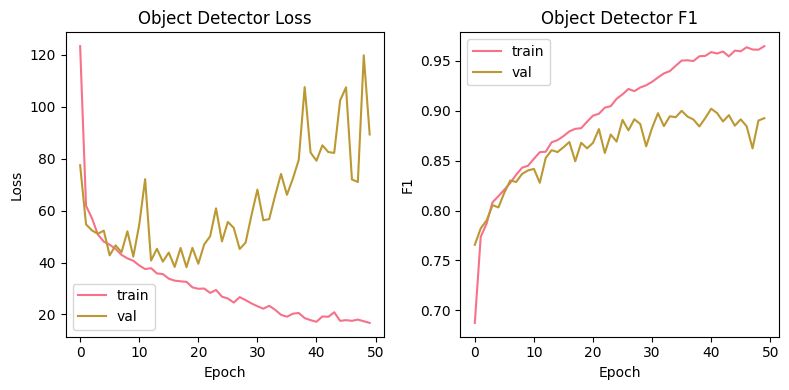

In [23]:
# detector learning curves
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(detector_history.history['loss'], label='train')
if 'val_loss' in detector_history.history:
    plt.plot(detector_history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Object Detector Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(detector_history.history['f1_41'], label='train')
if 'val_f1_41' in detector_history.history:
    plt.plot(detector_history.history['val_f1_41'], label='val')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('Object Detector F1')
plt.legend()

plt.tight_layout()
plt.show()

Detector test loss: 85.6221
Detector test f1_41: 0.8675
Presence precision: 1.0000
Presence recall: 0.9938
Presence F1: 0.9969
Mean localization error: 0.42 pixels


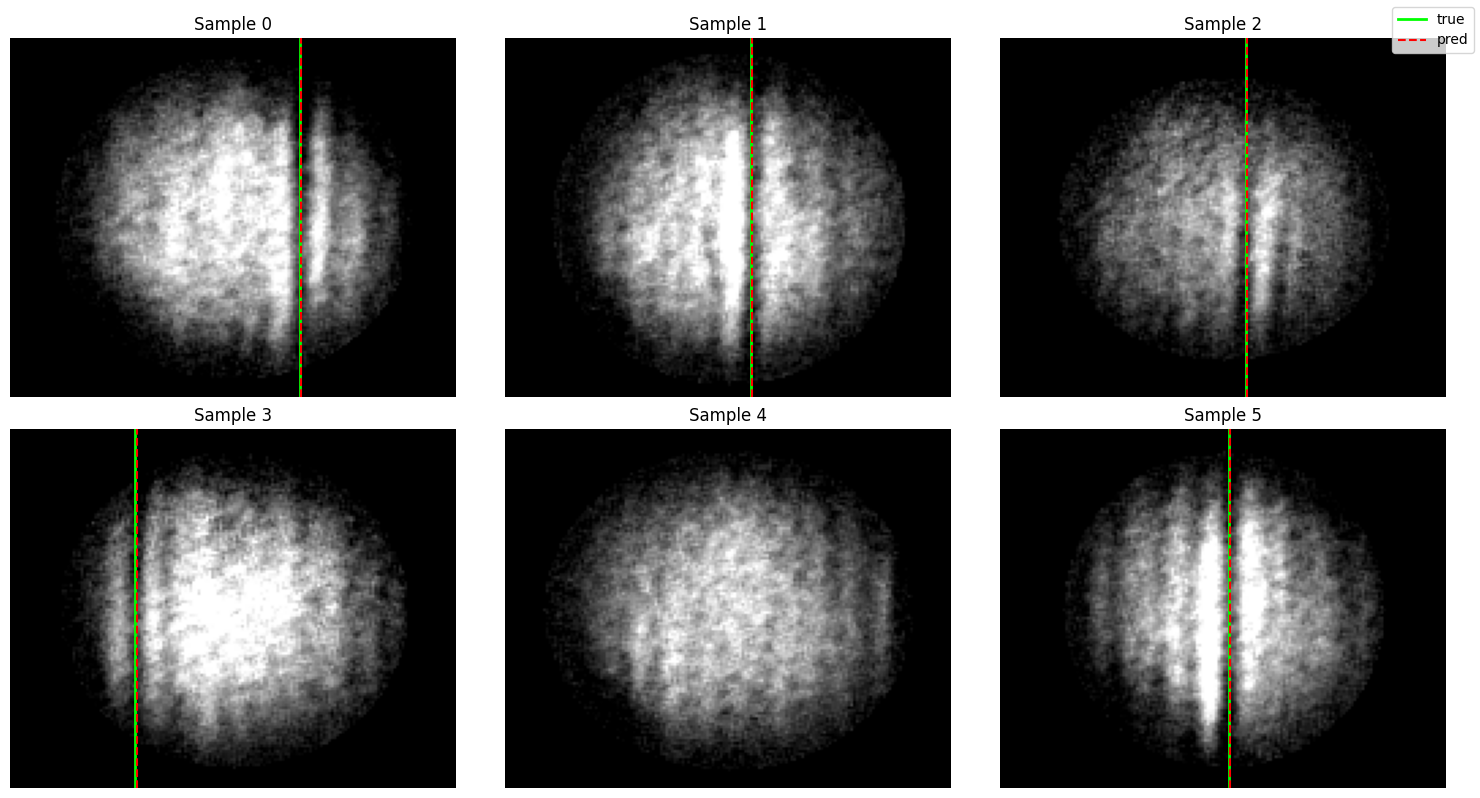

In [24]:
# held-out detector eval
object_detector_test_loss, object_detector_test_f1 = object_detector.evaluate(
    X_test_det,
    y_test_det_41,
    verbose=0,
)

object_detector_pred = object_detector.predict(X_test_det, verbose=0)
predicted_positions = labels41_to_positions(object_detector_pred)
true_positions = [normalize_position_list(pos_list) for pos_list in pos_test_det]

presence_true = np.array([len(pos_list) > 0 for pos_list in true_positions], dtype=np.int32)
presence_pred = np.array([len(pos_list) > 0 for pos_list in predicted_positions], dtype=np.int32)

true_positive = int(np.sum((presence_true == 1) & (presence_pred == 1)))
false_positive = int(np.sum((presence_true == 0) & (presence_pred == 1)))
false_negative = int(np.sum((presence_true == 1) & (presence_pred == 0)))
precision = true_positive / max(true_positive + false_positive, 1)
recall = true_positive / max(true_positive + false_negative, 1)
presence_f1 = 2 * precision * recall / max(precision + recall, 1e-8)

localization_errors = []
for true_pos, pred_pos in zip(true_positions, predicted_positions):
    if true_pos and pred_pos:
        localization_errors.append(abs(pred_pos[0] - true_pos[0]))

mean_localization_error = float(np.mean(localization_errors)) if localization_errors else float('nan')

print(f"Detector test loss: {object_detector_test_loss:.4f}")
print(f"Detector test f1_41: {object_detector_test_f1:.4f}")
print(f"Presence precision: {precision:.4f}")
print(f"Presence recall: {recall:.4f}")
print(f"Presence F1: {presence_f1:.4f}")
print(f"Mean localization error: {mean_localization_error:.2f} pixels")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for axis, sample_idx in zip(axes, range(min(6, len(X_test_det)))):
    axis.imshow(X_test_det[sample_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    for true_pos in true_positions[sample_idx]:
        axis.axvline(true_pos, color='lime', linewidth=2, label='true')
    for pred_pos in predicted_positions[sample_idx]:
        axis.axvline(pred_pos, color='red', linewidth=1.5, linestyle='--', label='pred')
    axis.set_title(f"Sample {sample_idx}")
    axis.axis('off')

handles, labels_for_legend = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles[:2], labels_for_legend[:2], loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
# standalone pie + quality stage
# copied/adjusted from SolDet

class MexicanHatMetric:
    """Lightweight Mahalanobis-style metric for soliton profile quality scoring."""
    def __init__(self, regularization=1e-6):
        self.regularization = regularization
        self.mean_ = None
        self.inv_cov_ = None

    def _features_for_position(self, img2d, pos):
        h, w = img2d.shape
        x = int(np.clip(round(float(pos)), 0, w - 1))

        x0 = max(0, x - 2)
        x1 = min(w, x + 3)
        col_profile = np.mean(img2d[:, x0:x1], axis=1)

        amp = float(np.max(col_profile) - np.min(col_profile))
        min_idx = int(np.argmin(col_profile))
        center_offset = float(min_idx - (h / 2.0)) / (h / 2.0)

        min_val = float(np.min(col_profile))
        max_val = float(np.max(col_profile))
        half_level = min_val + 0.5 * (max_val - min_val)
        below = np.where(col_profile <= half_level)[0]
        width = float(len(below)) / max(h, 1)

        top = col_profile[h // 2:]
        bottom = col_profile[:h // 2]
        mean_diff = float(np.mean(top) - np.mean(bottom))
        grad_top = float(np.mean(np.diff(top))) if len(top) > 1 else 0.0
        grad_bottom = float(np.mean(np.diff(bottom))) if len(bottom) > 1 else 0.0
        grad_diff = grad_top - grad_bottom

        return np.array([amp, center_offset, width, mean_diff, grad_diff], dtype=np.float64)

    def fit(self, images, positions):
        feats = []
        for img, pos_list in zip(images, positions):
            img2d = np.squeeze(img)
            if not isinstance(pos_list, list) or len(pos_list) == 0:
                continue
            feats.append(self._features_for_position(img2d, pos_list[0]))

        if len(feats) == 0:
            self.mean_ = None
            self.inv_cov_ = None
            return

        X = np.vstack(feats)
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        if cov.ndim == 0:
            cov = np.array([[float(cov)]], dtype=np.float64)
        cov = cov + self.regularization * np.eye(cov.shape[0], dtype=np.float64)
        self.inv_cov_ = np.linalg.pinv(cov)

    def predict(self, image, positions):
        if self.mean_ is None or self.inv_cov_ is None:
            return [np.nan for _ in positions]

        img2d = np.squeeze(image)
        scores = []
        for pos in positions:
            feat = self._features_for_position(img2d, pos)
            d = feat - self.mean_
            m2 = float(d.T @ self.inv_cov_ @ d)
            score = float(np.exp(-0.5 * m2))
            scores.append(score)
        return scores


def pie_profile_features(img2d, position):
    """Return core asymmetry features for PIE-type decision rules."""
    h, w = img2d.shape
    x = int(np.clip(round(float(position[0])), 0, w - 1))
    x0 = max(0, x - 2)
    x1 = min(w, x + 3)
    col_profile = np.mean(img2d[:, x0:x1], axis=1)

    top = col_profile[h // 2:]
    bottom = col_profile[:h // 2]

    amp_top = float(np.max(top) - np.min(top)) if len(top) > 0 else 0.0
    amp_bottom = float(np.max(bottom) - np.min(bottom)) if len(bottom) > 0 else 0.0
    amp_diff = amp_top - amp_bottom

    min_top = int(np.argmin(top)) if len(top) > 0 else 0
    min_bottom = int(np.argmin(bottom)) if len(bottom) > 0 else 0
    pos_diff = float((min_top + h // 2) - min_bottom) / max(h, 1)

    top_grad = float(np.mean(np.diff(top))) if len(top) > 1 else 0.0
    bottom_grad = float(np.mean(np.diff(bottom))) if len(bottom) > 1 else 0.0
    grad_diff = top_grad - bottom_grad

    return amp_diff, pos_diff, grad_diff


def classify_solitonic_excitation(img2d, position, thresholds=None):
    """Heuristic PIE-type classifier with output coding 0..5."""
    default_thresholds = {
        'amp_partial': 0.08,
        'grad_vortex': 0.004,
        'pos_tilted': 0.08,
        'longitudinal_amp': 0.05,
        'longitudinal_grad': 0.0025,
        'longitudinal_pos': 0.05,
    }
    rules = thresholds if thresholds is not None else globals().get('PIE_RULES', default_thresholds)

    amp_diff, pos_diff, grad_diff = pie_profile_features(img2d, position)

    # type 0 is our near-symmetric longitudinal case
    if (
        abs(amp_diff) <= rules['longitudinal_amp']
        and abs(grad_diff) <= rules['longitudinal_grad']
        and abs(pos_diff) <= rules['longitudinal_pos']
    ):
        return 0

    if amp_diff > rules['amp_partial']:
        return 1
    if amp_diff < -rules['amp_partial']:
        return 2
    if grad_diff < -rules['grad_vortex']:
        return 3
    if grad_diff > rules['grad_vortex']:
        return 4
    if abs(pos_diff) > rules['pos_tilted']:
        return 5
    return 0

In [26]:
# collect single-excitation examples for pie/qe calibration
single_train_images = []
single_train_positions = []
for img, label, pos in zip(X_train, y_train, pos_train):
    if int(label) == 1 and isinstance(pos, list) and len(pos) > 0:
        single_train_images.append(img.squeeze())
        single_train_positions.append([float(pos[0])])

single_train_images = np.array(single_train_images, dtype=np.float32)
print(f"Single-excitation samples for PIE/QE setup: {len(single_train_images)}")

# tune pie thresholds from this training subset instead of hard-coding
PIE_RULES = {
    'amp_partial': 0.08,
    'grad_vortex': 0.004,
    'pos_tilted': 0.08,
    'longitudinal_amp': 0.05,
    'longitudinal_grad': 0.0025,
    'longitudinal_pos': 0.05,
}

if len(single_train_images) > 0:
    feat_rows = []
    for img, pos_list in zip(single_train_images, single_train_positions):
        amp_diff, pos_diff, grad_diff = pie_profile_features(img, pos_list)
        feat_rows.append([abs(amp_diff), abs(pos_diff), abs(grad_diff)])
    feat_rows = np.array(feat_rows, dtype=np.float64)

    # quantiles define a central/symmetric region for type-0
    PIE_RULES['longitudinal_amp'] = float(np.quantile(feat_rows[:, 0], 0.40))
    PIE_RULES['longitudinal_pos'] = float(np.quantile(feat_rows[:, 1], 0.40))
    PIE_RULES['longitudinal_grad'] = float(np.quantile(feat_rows[:, 2], 0.40))
    PIE_RULES['amp_partial'] = float(np.quantile(feat_rows[:, 0], 0.75))
    PIE_RULES['pos_tilted'] = float(np.quantile(feat_rows[:, 1], 0.75))
    PIE_RULES['grad_vortex'] = float(np.quantile(feat_rows[:, 2], 0.75))

print("PIE threshold rules:")
for key in [
    'longitudinal_amp',
    'longitudinal_pos',
    'longitudinal_grad',
    'amp_partial',
    'pos_tilted',
    'grad_vortex',
]:
    print(f"  {key}: {PIE_RULES[key]:.6f}")

Single-excitation samples for PIE/QE setup: 2891
PIE threshold rules:
  longitudinal_amp: 0.045266
  longitudinal_pos: 0.750000
  longitudinal_grad: 0.011280
  amp_partial: 0.096552
  pos_tilted: 0.825758
  grad_vortex: 0.016354


In [27]:
# fit pie metric on the single-excitation subset
pie_metric = MexicanHatMetric()
if len(single_train_images) > 0:
    pie_metric.fit(single_train_images, single_train_positions)
    print("Standalone PIE metric initialized.")
else:
    print("No single-excitation samples available; PIE metric is empty.")

# then fit qe only on detections labeled type-0 by pie
longitudinal_train_images = []
longitudinal_train_positions = []
for img, pos_list in zip(single_train_images, single_train_positions):
    pie_type = int(classify_solitonic_excitation(img, pos_list, thresholds=PIE_RULES))
    if pie_type == 0:
        longitudinal_train_images.append(img)
        longitudinal_train_positions.append(pos_list)

quality_estimator = MexicanHatMetric()
if len(longitudinal_train_images) > 0:
    quality_estimator.fit(np.array(longitudinal_train_images, dtype=np.float32), longitudinal_train_positions)
    print(f"Quality estimator fitted on {len(longitudinal_train_images)} longitudinal samples.")
else:
    print("No longitudinal samples found by standalone PIE; quality estimator not fitted.")

Standalone PIE metric initialized.
Quality estimator fitted on 1431 longitudinal samples.


Pipeline terminated at CNN/OD gate for 125/538 samples
Total OD detections on held-out split: 474
Total PIE type-0 detections: 237
Total quality-scored detections: 237


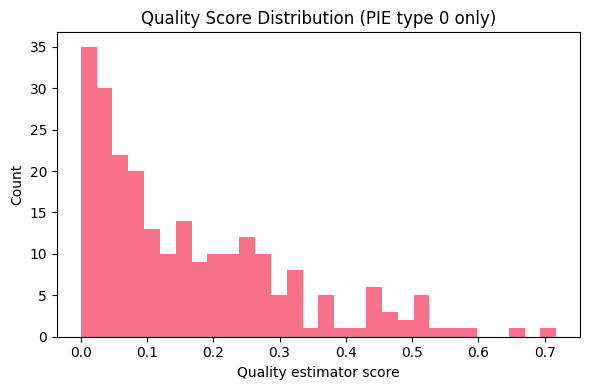

In [28]:
# now run the full sequential gate on held-out samples
classifier_pred_labels_full = np.argmax(classifier.predict(X_test, verbose=0), axis=1)
od_pred_full = object_detector.predict(X_test, verbose=0)
od_positions_full = labels41_to_positions(od_pred_full)

pipeline_pie_types = []
pipeline_quality_scores = []
pipeline_accepted_positions = []
terminated_count = 0

for img, cls_label, od_positions in zip(X_test, classifier_pred_labels_full, od_positions_full):
    # if cnn says none or od finds none, we stop early for that sample
    if int(cls_label) == 0 or len(od_positions) == 0:
        pipeline_pie_types.append([])
        pipeline_quality_scores.append([])
        pipeline_accepted_positions.append([])
        terminated_count += 1
        continue

    img2d = img.squeeze()
    pie_types = []
    q_scores = []
    accepted_positions = []

    for pos in od_positions:
        pos_float = float(pos)
        pie_type = int(classify_solitonic_excitation(img2d, [pos_float], thresholds=PIE_RULES))
        pie_types.append(pie_type)

        if pie_type == 0 and len(longitudinal_train_images) > 0:
            q = quality_estimator.predict(img2d, positions=[pos_float])[0]
            q_scores.append(float(q))
            accepted_positions.append(pos_float)
        else:
            q_scores.append(float('nan'))

    pipeline_pie_types.append(pie_types)
    pipeline_quality_scores.append(q_scores)
    pipeline_accepted_positions.append(accepted_positions)

total_detections = sum(len(p) for p in od_positions_full)
total_longitudinal = sum(sum(1 for t in types if t == 0) for types in pipeline_pie_types)
total_quality_scored = sum(sum(np.isfinite(np.array(scores))) for scores in pipeline_quality_scores)

print(f"Pipeline terminated at CNN/OD gate for {terminated_count}/{len(X_test)} samples")
print(f"Total OD detections on held-out split: {total_detections}")
print(f"Total PIE type-0 detections: {total_longitudinal}")
print(f"Total quality-scored detections: {total_quality_scored}")

# qe scores for type-0 detections
all_quality_scores = [
    score
    for score_list in pipeline_quality_scores
    for score in score_list
    if np.isfinite(score)
]

if len(all_quality_scores) > 0:
    plt.figure(figsize=(6, 4))
    plt.hist(all_quality_scores, bins=30)
    plt.xlabel('Quality estimator score')
    plt.ylabel('Count')
    plt.title('Quality Score Distribution (PIE type 0 only)')
    plt.tight_layout()
    plt.show()

## 11. Classifier ROC Curves

One-vs-rest ROC curves for each class, mainly to sanity-check discrimination beyond accuracy/F1.

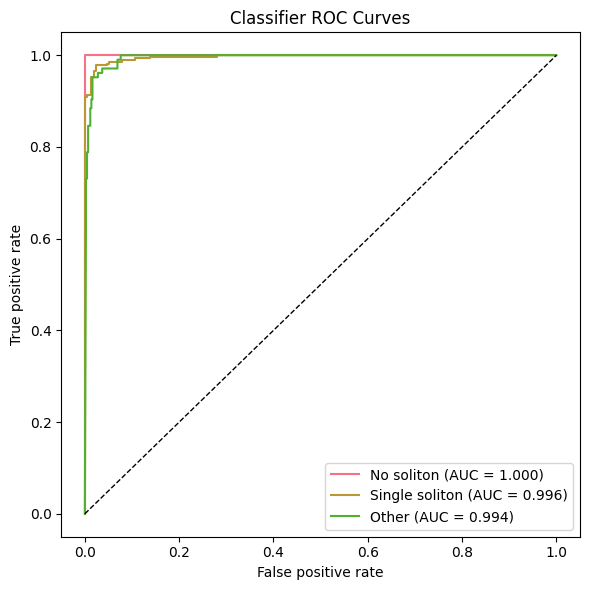

In [29]:
# one-vs-rest roc view for the classifier
classifier_probabilities = classifier.predict(X_test, verbose=0)
class_names = ['No soliton', 'Single soliton', 'Other']

plt.figure(figsize=(6, 6))
for class_idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, class_idx], classifier_probabilities[:, class_idx])
    auc_score = roc_auc_score(y_test_onehot[:, class_idx], classifier_probabilities[:, class_idx])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Classifier ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Class Activation Maps (Grad-CAM)

Grad-CAM plots to see what image regions are driving classifier decisions.

In [49]:
def make_gradcam_heatmap(image_batch, model, layer_name, class_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(image_batch)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    gradients = tape.gradient(class_channel, conv_output)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    if float(max_value) > 0:
        heatmap = heatmap / max_value
    return heatmap.numpy(), class_index

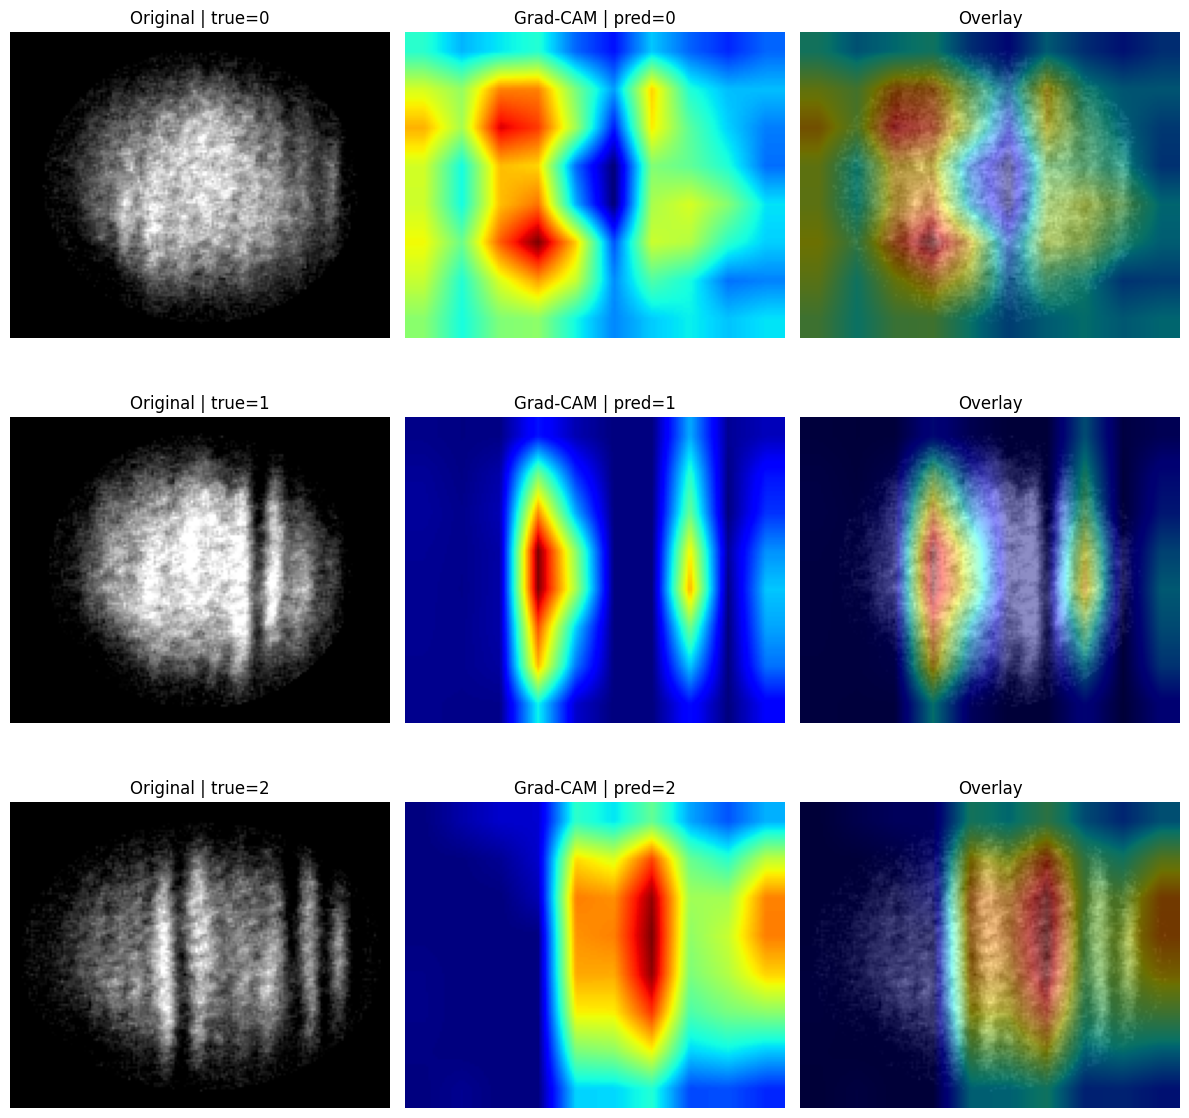

In [50]:
# grad-cam pass so we can inspect where the classifier is looking

last_conv_layer_name = [layer.name for layer in classifier.layers if isinstance(layer, tf.keras.layers.Conv2D)][-1]
selected_indices = []
for target_class in [0, 1, 2]:
    class_matches = np.where(y_test == target_class)[0]
    if len(class_matches) > 0:
        selected_indices.append(int(class_matches[0]))

fig, axes = plt.subplots(len(selected_indices), 3, figsize=(12, 4 * len(selected_indices)))
if len(selected_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, sample_idx in enumerate(selected_indices):
    input_image = X_test[sample_idx:sample_idx + 1]
    heatmap, predicted_class = make_gradcam_heatmap(input_image, classifier, last_conv_layer_name)
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (132, 164)).numpy().squeeze()

    axes[row_idx, 0].imshow(X_test[sample_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 0].set_title(f"Original | true={y_test[sample_idx]}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(heatmap_resized, cmap='jet')
    axes[row_idx, 1].set_title(f"Grad-CAM | pred={predicted_class}")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(X_test[sample_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 2].imshow(heatmap_resized, cmap='jet', alpha=0.45)
    axes[row_idx, 2].set_title('Overlay')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

Conv layers: ['conv2d_25', 'conv2d_26', 'conv2d_27', 'conv2d_28', 'conv2d_29']


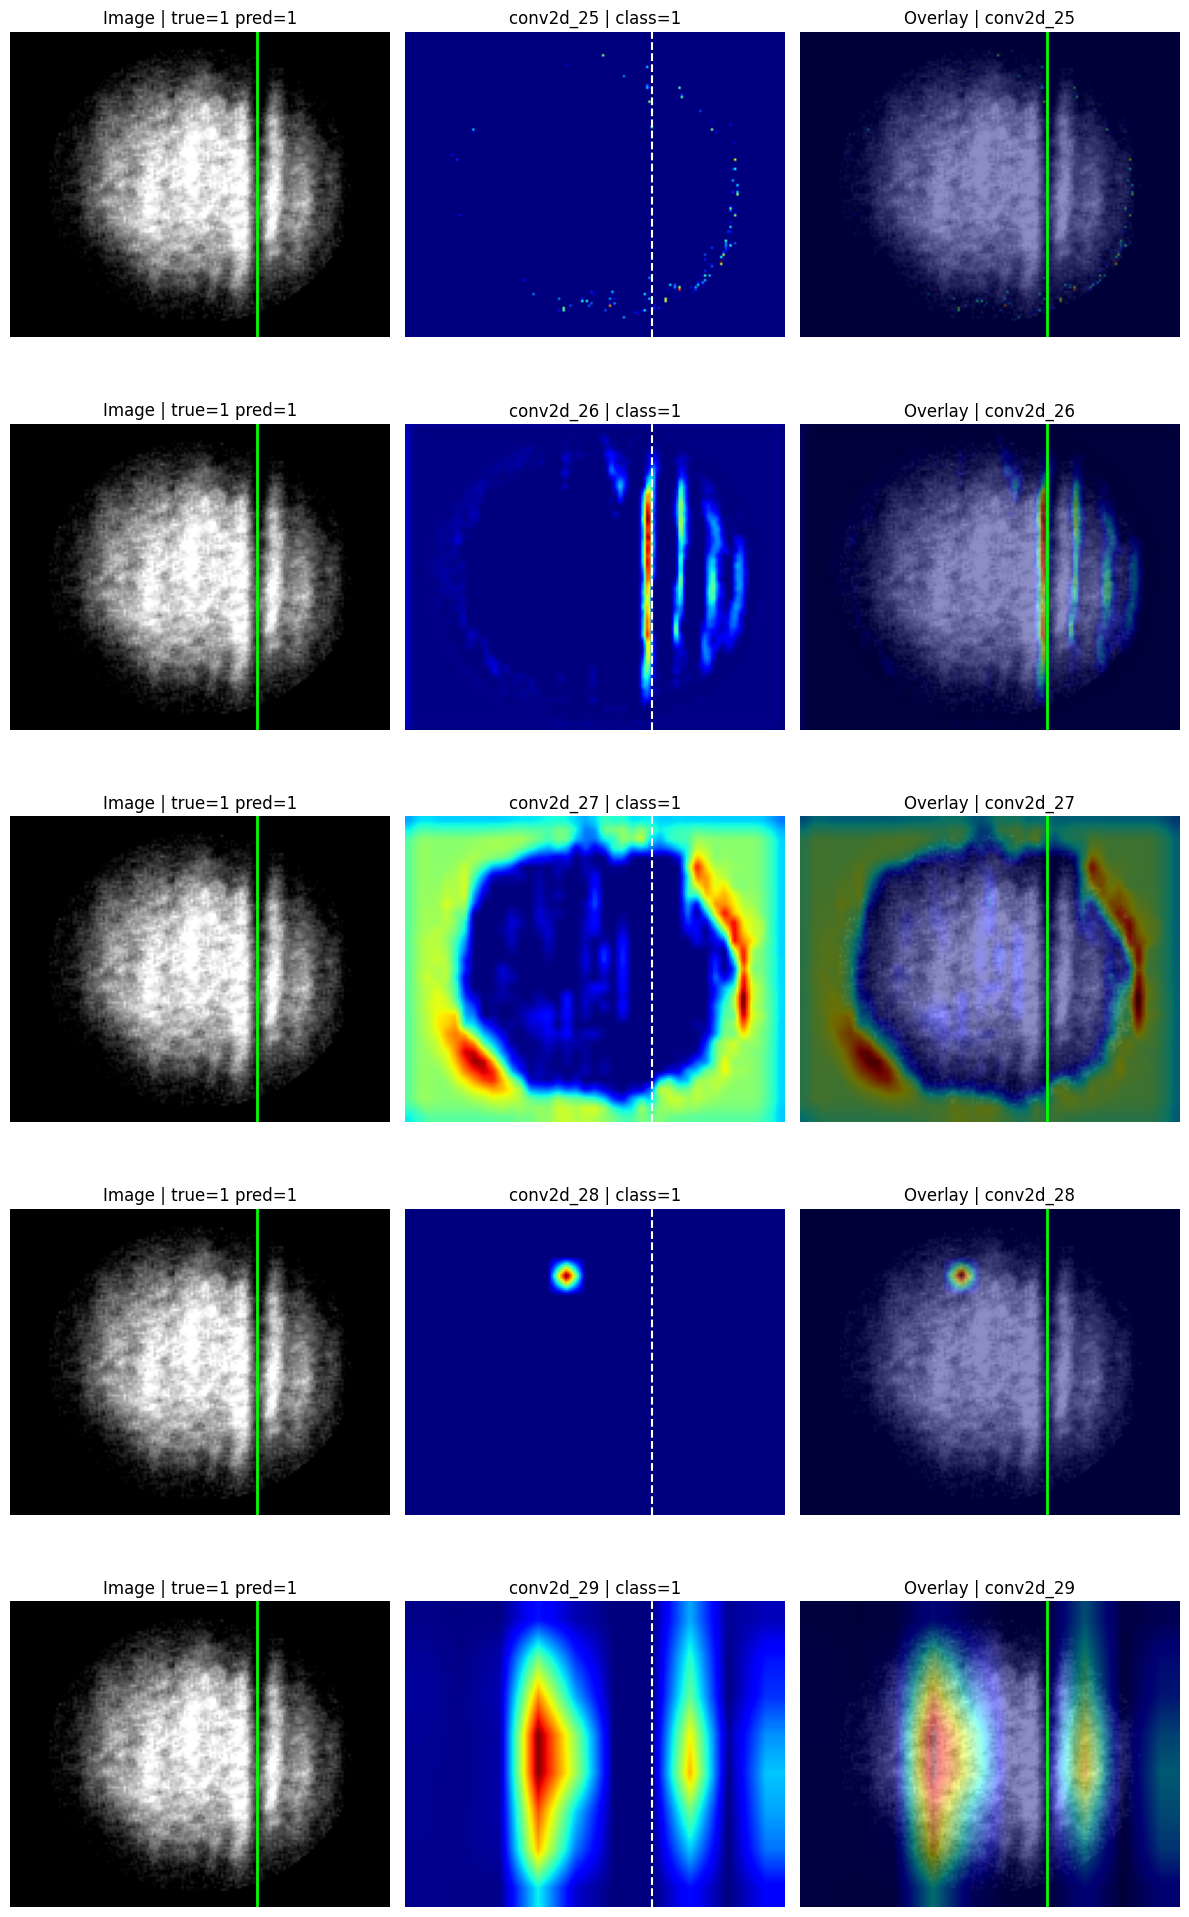

In [53]:
# quick side-by-side of grad-cam across earlier conv blocks
conv_layer_names = [layer.name for layer in classifier.layers if isinstance(layer, tf.keras.layers.Conv2D)]
print('Conv layers:', conv_layer_names)

sample_candidates = np.where(y_test == 1)[0]
sample_idx = int(sample_candidates[0]) if len(sample_candidates) > 0 else 0
input_image = X_test[sample_idx:sample_idx + 1]
true_label = int(y_test[sample_idx])
pred_label = int(np.argmax(classifier.predict(input_image, verbose=0)[0]))
reference_positions = pos_test[sample_idx]

fig, axes = plt.subplots(len(conv_layer_names), 3, figsize=(12, 4 * len(conv_layer_names)))
if len(conv_layer_names) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, layer_name in enumerate(conv_layer_names):
    heatmap, cam_class = make_gradcam_heatmap(input_image, classifier, layer_name, class_index=pred_label)
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (132, 164)).numpy().squeeze()

    axes[row_idx, 0].imshow(X_test[sample_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    for pos in reference_positions:
        axes[row_idx, 0].axvline(pos, color='lime', linewidth=2)
    axes[row_idx, 0].set_title(f'Image | true={true_label} pred={pred_label}')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(heatmap_resized, cmap='jet')
    for pos in reference_positions:
        axes[row_idx, 1].axvline(pos, color='white', linewidth=1.5, linestyle='--')
    axes[row_idx, 1].set_title(f'{layer_name} | class={cam_class}')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(X_test[sample_idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 2].imshow(heatmap_resized, cmap='jet', alpha=0.45)
    for pos in reference_positions:
        axes[row_idx, 2].axvline(pos, color='lime', linewidth=2)
    axes[row_idx, 2].set_title(f'Overlay | {layer_name}')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()